In [1]:
# Cell 1: Install & Login
!pip install -q -U pyarrow datasets transformers peft scikit-learn torchao optuna

import os, gc, json
from collections import Counter

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

from kaggle_secrets import UserSecretsClient
from huggingface_hub import login
hf_token = UserSecretsClient().get_secret("HF_TOKEN")
login(hf_token)
print("[INFO] Login OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 78.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 87.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 78.7 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-sto

In [2]:
# Cell 2: Imports & Config
import torch
import numpy as np
from torch.utils.data import Dataset, WeightedRandomSampler, DataLoader
from PIL import Image
from torchvision import transforms
from transformers import ViTForImageClassification, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, PeftModel
from datasets import load_dataset
from sklearn.metrics import (
    f1_score, accuracy_score,
    roc_auc_score, classification_report, confusion_matrix
)
from huggingface_hub import HfApi, list_repo_files, snapshot_download
import optuna

MODEL_ID   = "google/vit-base-patch16-224"
DATASET_ID = "marmal88/skin_cancer"
HUB_REPO   = "Ganymede981/ham10000-vit"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

# HAM10000 — 7 dermatoscopy classes (severe imbalance: nv ~67%, df/vasc <2%)
HAM_LABELS = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
NUM_CLASSES = len(HAM_LABELS)   # 7
LABEL2IDX  = {l: i for i, l in enumerate(HAM_LABELS)}
IDX2LABEL  = {i: l for i, l in enumerate(HAM_LABELS)}
print(f"[INFO] Device={DEVICE}  Classes={NUM_CLASSES}")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


[INFO] Device=cuda  Classes=7


In [3]:
# Cell 3: Load Dataset & Build Splits (Fixed)
# ─────────────────────────────────────────────────────────────────
# marmal88/skin_cancer has 'train' and 'test' splits.
# 'dx' is a plain string Value, NOT a ClassLabel → we must
# stratify manually via sklearn or cast to ClassLabel first.
# ─────────────────────────────────────────────────────────────────

from datasets import ClassLabel, Value
from sklearn.model_selection import train_test_split as sk_train_test_split
import numpy as np

print(f"[INFO] Loading {DATASET_ID}...")
raw = load_dataset(DATASET_ID)
print(raw)

sample0 = raw["train"][0]
print("[INFO] Sample keys:", list(sample0.keys()))

# ── 1. Detect label field ─────────────────────────────────────────
LABEL_FIELD = None
for field in ["dx", "label", "labels"]:
    if field in sample0:
        LABEL_FIELD = field
        break
print(f"[INFO] Label field : '{LABEL_FIELD}'")
print(f"[INFO] Raw value   : {sample0[LABEL_FIELD]}  (type: {type(sample0[LABEL_FIELD]).__name__})")

# ── 2. Collect unique class names & build mappings ────────────────
all_string_labels = raw["train"][LABEL_FIELD]          # list[str]
HAM_LABELS  = sorted(set(all_string_labels))           # deterministic order
NUM_CLASSES = len(HAM_LABELS)
LABEL2IDX   = {l: i for i, l in enumerate(HAM_LABELS)}
IDX2LABEL   = {i: l for i, l in enumerate(HAM_LABELS)}
print(f"[INFO] Classes ({NUM_CLASSES}): {HAM_LABELS}")

# ── 3. Cast 'dx' column to ClassLabel so HF knows it's categorical ─
new_features = raw["train"].features.copy()
new_features[LABEL_FIELD] = ClassLabel(names=HAM_LABELS)

raw["train"] = raw["train"].cast(new_features)
raw["test"]  = raw["test"].cast(new_features)          # keep test consistent

# Verify cast
feat = raw["train"].features[LABEL_FIELD]
print(f"[INFO] Feature type after cast : {feat}")      # ClassLabel(num_classes=7, ...)

# ── 4. Stratified 85 / 15 train-val split ────────────────────────
# Now that dx is a ClassLabel, HF's stratify_by_column works.
tv_split = raw["train"].train_test_split(
    test_size        = 0.15,
    seed             = 42,
    stratify_by_column = LABEL_FIELD,
)

train_raw = tv_split["train"]
val_raw   = tv_split["test"]
test_raw  = raw["test"]

print(f"\n[INFO] Split sizes  →  Train={len(train_raw):,}  "
      f"Val={len(val_raw):,}  Test={len(test_raw):,}")

# ── 5. Quick sanity-check: class distribution in each split ───────
def label_dist(dataset, field=LABEL_FIELD):
    counts = {}
    for idx in dataset[field]:                         # now integer indices
        counts[IDX2LABEL[idx]] = counts.get(IDX2LABEL[idx], 0) + 1
    total = sum(counts.values())
    return {k: f"{v} ({100*v/total:.1f}%)" for k, v in sorted(counts.items())}

print("\n[INFO] Train distribution :", label_dist(train_raw))
print("[INFO] Val   distribution :", label_dist(val_raw))
print("[INFO] Test  distribution :", label_dist(test_raw))

[INFO] Loading marmal88/skin_cancer...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005-7eed077f2f8e6d(…):   0%|          | 0.00/521M [00:00<?, ?B/s]

data/train-00001-of-00005-50ba64fd20294b(…):   0%|          | 0.00/525M [00:00<?, ?B/s]

data/train-00002-of-00005-36c02a25cbdd54(…):   0%|          | 0.00/527M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/1285 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 9577
    })
    validation: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 2492
    })
    test: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 1285
    })
})
[INFO] Sample keys: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
[INFO] Label field : 'dx'
[INFO] Raw value   : actinic_keratoses  (type: str)
[INFO] Classes (7): ['actinic_keratoses', 'basal_cell_carcinoma', 'benign_keratosis-like_lesions', 'dermatofibroma', 'melanocytic_Nevi', 'melanoma', 'vascular_lesions']


Casting the dataset:   0%|          | 0/9577 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1285 [00:00<?, ? examples/s]

[INFO] Feature type after cast : ClassLabel(names=['actinic_keratoses', 'basal_cell_carcinoma', 'benign_keratosis-like_lesions', 'dermatofibroma', 'melanocytic_Nevi', 'melanoma', 'vascular_lesions'])

[INFO] Split sizes  →  Train=8,140  Val=1,437  Test=1,285

[INFO] Train distribution : {'actinic_keratoses': '268 (3.3%)', 'basal_cell_carcinoma': '414 (5.1%)', 'benign_keratosis-like_lesions': '891 (10.9%)', 'dermatofibroma': '93 (1.1%)', 'melanocytic_Nevi': '5444 (66.9%)', 'melanoma': '914 (11.2%)', 'vascular_lesions': '116 (1.4%)'}
[INFO] Val   distribution : {'actinic_keratoses': '47 (3.3%)', 'basal_cell_carcinoma': '73 (5.1%)', 'benign_keratosis-like_lesions': '157 (10.9%)', 'dermatofibroma': '17 (1.2%)', 'melanocytic_Nevi': '961 (66.9%)', 'melanoma': '162 (11.3%)', 'vascular_lesions': '20 (1.4%)'}
[INFO] Test  distribution : {'actinic_keratoses': '42 (3.3%)', 'basal_cell_carcinoma': '67 (5.2%)', 'benign_keratosis-like_lesions': '142 (11.1%)', 'dermatofibroma': '14 (1.1%)', 'melanocy

In [4]:
# Training-mode flag removed — train_collate_fn / eval_collate_fn split
# handles augmentation routing without a shared mutable global.


In [5]:
# Cell 4: Dataset Class + Collators
# Two separate collate functions replace the fragile _TRAINING_MODE global:
#   train_collate_fn  → applies CutMix/Mixup  (used only by get_train_dataloader)
#   eval_collate_fn   → hard labels only       (used for val/test)

class HAMDataset(Dataset):
    def __init__(self, hf_split, augment=False, image_size=224):
        self.data = hf_split
        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((256, 256)),
                transforms.RandomCrop(image_size),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(30),
                transforms.ColorJitter(brightness=0.4, contrast=0.4,
                                       saturation=0.2, hue=0.05),
                transforms.RandomGrayscale(p=0.05),
                transforms.ToTensor(),
                transforms.Normalize([0.7630, 0.5456, 0.5700],
                                     [0.1409, 0.1521, 0.1697]),  # HAM10000 stats
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
                transforms.Normalize([0.7630, 0.5456, 0.5700],
                                     [0.1409, 0.1521, 0.1697]),
            ])

    def __len__(self):
        return len(self.data)

    def _get_label(self, sample) -> int:
        raw = sample[LABEL_FIELD]
        if isinstance(raw, int):  return raw
        if isinstance(raw, str):  return LABEL2IDX[raw.strip().lower()]
        return int(raw)

    def __getitem__(self, idx):
        s   = self.data[idx]
        img = s.get("image", s.get("img"))
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img = img.convert("RGB")
        return {"pixel_values": self.transform(img),
                "labels": self._get_label(s)}


from torchvision.transforms import v2 as T2

cutmix_fn = T2.CutMix(num_classes=NUM_CLASSES, alpha=1.0)
mixup_fn  = T2.MixUp(num_classes=NUM_CLASSES, alpha=0.4)

def train_collate_fn(batch):
    """Used only by HAMTrainer.get_train_dataloader — applies CutMix/Mixup."""
    pixel_values = torch.stack([b["pixel_values"] for b in batch])
    labels = torch.tensor([b["labels"] for b in batch], dtype=torch.long)
    r = torch.rand(1).item()
    if r < 0.5:
        pixel_values, labels = cutmix_fn(pixel_values, labels)
    else:
        pixel_values, labels = mixup_fn(pixel_values, labels)
    return {"pixel_values": pixel_values, "labels": labels}

def eval_collate_fn(batch):
    """Used for val/test — hard labels only, no augmentation."""
    pixel_values = torch.stack([b["pixel_values"] for b in batch])
    labels = torch.tensor([b["labels"] for b in batch], dtype=torch.long)
    return {"pixel_values": pixel_values, "labels": labels}

# Instantiate PyTorch datasets — must happen before Cell 5 (sampler) and Cell 10
train_ds = HAMDataset(train_raw, augment=True)
val_ds   = HAMDataset(val_raw,   augment=False)
test_ds  = HAMDataset(test_raw,  augment=False)
print(f"[INFO] train={len(train_ds):,}  val={len(val_ds):,}  test={len(test_ds):,}")


[INFO] train=8,140  val=1,437  test=1,285


In [6]:
# Cell 5: Class Weights & WeightedRandomSampler
# HAM10000 is severely imbalanced (nv ~58x more than df).
# Strategy: focal loss alpha-weights + WeightedRandomSampler on train set.
print("[INFO] Computing class distribution...")
train_labels = train_raw[LABEL_FIELD]
if isinstance(train_labels[0], str):
    train_labels = [LABEL2IDX[l] for l in train_labels]
train_labels = list(train_labels)

counts = Counter(train_labels)
counts_t = torch.tensor([counts[i] for i in range(NUM_CLASSES)], dtype=torch.float32)
total    = counts_t.sum()

# Alpha weights for focal loss — inverse frequency, clamped [0.5, 20]
class_weights = (total / (NUM_CLASSES * counts_t)).clamp(0.5, 20.0).to(DEVICE)

# Per-sample weights for WeightedRandomSampler (oversamples minority classes)
sample_weights = torch.tensor(
    [1.0 / counts[l] for l in train_labels], dtype=torch.float64
)
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("[INFO] Class distribution + weights:")
for i in range(NUM_CLASSES):
    print(f"  {HAM_LABELS[i]:<8}  count={counts[i]:>5}  "
          f"({100*counts[i]/total:.1f}%)  weight={class_weights[i]:.2f}")

[INFO] Computing class distribution...
[INFO] Class distribution + weights:
  actinic_keratoses  count=  268  (3.3%)  weight=4.34
  basal_cell_carcinoma  count=  414  (5.1%)  weight=2.81
  benign_keratosis-like_lesions  count=  891  (10.9%)  weight=1.31
  dermatofibroma  count=   93  (1.1%)  weight=12.50
  melanocytic_Nevi  count= 5444  (66.9%)  weight=0.50
  melanoma  count=  914  (11.2%)  weight=1.27
  vascular_lesions  count=  116  (1.4%)  weight=10.02


In [7]:
# Cell 6: Metrics
# Medical imaging: accuracy alone is misleading; use macro-F1 and macro-AUC
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()
    metrics = {
        "accuracy":    float(accuracy_score(labels, preds)),
        "f1_macro":    float(f1_score(labels, preds, average="macro",    zero_division=0)),
        "f1_weighted": float(f1_score(labels, preds, average="weighted", zero_division=0)),
    }
    try:
        metrics["roc_auc_macro"] = float(
            roc_auc_score(labels, probs, multi_class="ovr", average="macro")
        )
    except Exception:
        metrics["roc_auc_macro"] = 0.0
    return metrics

print("[INFO] compute_metrics ready.")

[INFO] compute_metrics ready.


In [8]:
# Cell 7: Model Builder
# DINOv2Classifier is a plain nn.Module wrapping facebook/dinov2-base.
# dinov2-base (86M params, hidden=768) keeps us within Kaggle P100 16 GB VRAM.
# Gradient checkpointing is enabled directly on the backbone since
# DINOv2Classifier is not a HF PreTrainedModel.
#
# IMPORTANT: forward() must return a dataclass/NamedTuple, NOT a dynamic
# anonymous class. DataParallel.gather() iterates over the output to merge
# across GPUs — a plain object with no __iter__ raises TypeError.

from dataclasses import dataclass
from transformers import Dinov2Model
import torch.nn as nn
from peft import LoraConfig, get_peft_model
from transformers.utils import ModelOutput as HFModelOutput
from dataclasses import dataclass
import torch

@dataclass
class ModelOutput(HFModelOutput):
    logits: torch.Tensor = None

class DINOv2Classifier(nn.Module):
    def __init__(self, num_classes=7, dropout=0.1):
        super().__init__()
        self.dinov2 = Dinov2Model.from_pretrained("facebook/dinov2-base")
        hidden = self.dinov2.config.hidden_size  # 768 for -base
        self.head = nn.Sequential(
            nn.LayerNorm(hidden * 2),
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, num_classes)
        )

    def forward(self, pixel_values, labels=None):
        out = self.dinov2(pixel_values=pixel_values)
        # Concatenate [CLS] token + mean of patch tokens (DINOv2 best practice)
        cls  = out.last_hidden_state[:, 0]
        mean = out.last_hidden_state[:, 1:].mean(dim=1)
        feats  = torch.cat([cls, mean], dim=1)
        logits = self.head(feats)
        return ModelOutput(logits=logits)
        

def build_model(lora_r=32, lora_alpha=64, lora_dropout=0.05):
    model = DINOv2Classifier(num_classes=NUM_CLASSES, dropout=0.1)
    lora_cfg = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        target_modules=["query", "value", "out_proj"],
        lora_dropout=lora_dropout,
        bias="none",
    )
    model.dinov2 = get_peft_model(model.dinov2, lora_cfg)
    # Enable gradient checkpointing directly on the backbone
    model.dinov2.base_model.model.gradient_checkpointing_enable(
        gradient_checkpointing_kwargs={"use_reentrant": False}
    )
    model.dinov2.print_trainable_parameters()
    return model

print("[INFO] build_model ready.")


[INFO] build_model ready.


In [9]:
# Cell 8: Loss Function + Custom Trainer
# SoftTargetCrossEntropy handles both hard labels (LongTensor) and soft labels
# (FloatTensor) from CutMix/Mixup.
# HAMTrainer overrides get_train_dataloader (WeightedRandomSampler + train_collate_fn)
# and get_eval_dataloader (eval_collate_fn — no augmentation).

import torch.nn.functional as F

class SoftTargetCrossEntropy(nn.Module):
    """
    Handles both hard labels (LongTensor) and soft labels (FloatTensor from
    CutMix/Mixup). With WeightedRandomSampler already balancing batches,
    class-weighted CE is sufficient — no focal term needed.
    """
    def __init__(self, weight=None, label_smoothing=0.05):
        super().__init__()
        self.weight = weight
        self.ls     = label_smoothing

    def forward(self, logits, labels):
        if labels.ndim == 1:
            # Hard labels — standard weighted CE
            return F.cross_entropy(
                logits, labels,
                weight=self.weight,
                label_smoothing=self.ls
            )
        else:
            # Soft labels from CutMix/Mixup — manual CE with label smoothing
            n = logits.size(1)
            labels = labels * (1 - self.ls) + self.ls / n
            log_p  = F.log_softmax(logits, dim=-1)
            if self.weight is not None:
                w = (labels * self.weight).sum(dim=-1)
                loss = -(labels * log_p).sum(dim=-1) * w
            else:
                loss = -(labels * log_p).sum(dim=-1)
            return loss.mean()


class HAMTrainer(Trainer):
    def get_train_dataloader(self):
        """Injects WeightedRandomSampler + CutMix/Mixup collator for training."""
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.per_device_train_batch_size,
            sampler=sampler,
            collate_fn=train_collate_fn,   # augmentation ON
            num_workers=4,
            pin_memory=True,
        )

    def get_eval_dataloader(self, eval_dataset=None):
        """Uses plain eval_collate_fn — no CutMix/Mixup, hard labels only."""
        ds = eval_dataset if eval_dataset is not None else self.eval_dataset
        return DataLoader(
            ds,
            batch_size=self.args.per_device_eval_batch_size,
            shuffle=False,
            collate_fn=eval_collate_fn,    # augmentation OFF
            num_workers=4,
            pin_memory=True,
        )

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss    = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

print("[INFO] SoftTargetCrossEntropy & HAMTrainer defined.")


[INFO] SoftTargetCrossEntropy & HAMTrainer defined.


In [10]:
# Cell 9: Hyperparameters
# - LR 3e-4  (LoRA keeps backbone mostly frozen; slightly higher LR is fine)
# - 60 epochs with early stopping patience=8 (cosine LR, small dataset)
# - Effective batch = 32 * 2 accum = 64
# - Cosine LR with 10% warmup
# - Weight decay 0.05  (strong regularisation for small dataset)
# - Label smoothing 0.05

BEST_LR      = 3e-4
BEST_LORA_R  = 32
BEST_DROPOUT = 0.1

loss_fn = SoftTargetCrossEntropy(
    weight=class_weights,   # from Cell 5, already on DEVICE
    label_smoothing=0.05
)
print(f"[INFO] LR={BEST_LR:.1e}  LoRA r={BEST_LORA_R}  dropout={BEST_DROPOUT}  label_smooth=0.05")


[INFO] LR=3.0e-04  LoRA r=32  dropout=0.1  label_smooth=0.05


In [14]:
# Cell 10: Full Training Run
# ── Checkpointing strategy ────────────────────────────────────────────────────
# hub_strategy="checkpoint" pushes every saved checkpoint to HuggingFace Hub.
# If the Kaggle session dies, /kaggle/working/ is wiped but Hub survives.
# Leave FORCE_RESTART=False permanently — auto-detects fresh vs resume.

import glob as _glob

gc.collect(); torch.cuda.empty_cache()
print(f"[INFO] GPU free: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

HfApi().create_repo(HUB_REPO, token=hf_token, exist_ok=True)

# ── Attempt to resume; fall through to fresh start on any failure ─────────────
resume_from = None
model       = None

try:
    files = list(list_repo_files(HUB_REPO, token=hf_token))
    print(f"[DEBUG] Hub files (first 10): {files[:10]}")

    # hub_strategy="checkpoint" saves to "last-checkpoint/" on Hub, not "checkpoint-N/"
    hub_folders = {f.split("/")[0] for f in files}
    has_last_checkpoint = "last-checkpoint" in hub_folders

    # Also catch any numbered checkpoint-N folders just in case
    numbered = sorted(
        {f for f in hub_folders if f.startswith("checkpoint-")},
        key=lambda p: int(p.split("-")[-1])
    )
    resume_folder = "last-checkpoint" if has_last_checkpoint else (numbered[-1] if numbered else None)
    print(f"[INFO] Resume folder on Hub: {resume_folder}")

    if resume_folder:
        print("[INFO] Checkpoint found on Hub — downloading...")
        local = snapshot_download(
            HUB_REPO, token=hf_token,
            local_dir="/kaggle/working/resume"
        )
        resume_from = os.path.join(local, resume_folder)
        print(f"[INFO] Resuming from {resume_from}")

        model = build_model(BEST_LORA_R, BEST_LORA_R * 2, BEST_DROPOUT)
        lora_dir  = os.path.join(resume_from, "dinov2_lora")
        head_path = os.path.join(resume_from, "head.pt")
        if os.path.isdir(lora_dir):
            from peft import PeftModel
            model.dinov2 = PeftModel.from_pretrained(
                model.dinov2.base_model.model,
                lora_dir, is_trainable=True
            )
            print("[INFO] LoRA weights loaded.")
        if os.path.isfile(head_path):
            model.head.load_state_dict(torch.load(head_path, map_location="cpu"))
            print("[INFO] Head weights loaded.")
    else:
        print("[INFO] No checkpoints on Hub — starting fresh.")

except Exception as e:
    print(f"[INFO] Hub lookup failed ({e}) — starting fresh.")

if model is None:
    model = build_model(BEST_LORA_R, BEST_LORA_R * 2, BEST_DROPOUT)

model.to(DEVICE)

# ── Training Arguments ────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="/kaggle/working/checkpoints",
    num_train_epochs=60,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=2,
    learning_rate=BEST_LR,
    lr_scheduler_type="cosine",
    warmup_ratio=0.10,
    weight_decay=0.05,
    fp16=True,
    optim="adamw_torch_fused",
    logging_steps=50,
    save_strategy="epoch",
    eval_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    push_to_hub=True,
    hub_model_id=HUB_REPO,
    hub_strategy="checkpoint",
    hub_token=hf_token,
    report_to="none",
    dataloader_num_workers=0,
    remove_unused_columns=False,
)

model.dinov2.print_trainable_parameters()

from transformers import EarlyStoppingCallback

trainer = HAMTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=eval_collate_fn,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=8)],
)

print(f"[INFO] {'Resuming' if resume_from else 'Starting fresh'} training...")
trainer.train(resume_from_checkpoint=resume_from)

# ── Save final model ──────────────────────────────────────────────────────────
os.makedirs("/kaggle/working/final_model/dinov2_lora", exist_ok=True)
model.dinov2.save_pretrained("/kaggle/working/final_model/dinov2_lora")
torch.save(model.head.state_dict(), "/kaggle/working/final_model/head.pt")
print("[INFO] Final model saved locally.")

from huggingface_hub import upload_folder
upload_folder(
    repo_id=HUB_REPO,
    folder_path="/kaggle/working/final_model",
    commit_message="HAM10000 DINOv2-LoRA final",
    token=hf_token,
)
print("[INFO] Done. Model pushed to Hub.")

[INFO] GPU free: 14.22 GB
[DEBUG] Hub files (first 10): ['.gitattributes', 'README.md', 'adapter_config.json', 'adapter_model.safetensors', 'last-checkpoint/README.md', 'last-checkpoint/adapter_config.json', 'last-checkpoint/adapter_model.safetensors', 'last-checkpoint/model.safetensors', 'last-checkpoint/optimizer.pt', 'last-checkpoint/rng_state.pth']
[INFO] Resume folder on Hub: last-checkpoint
[INFO] Checkpoint found on Hub — downloading...


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

[INFO] Resuming from /kaggle/working/resume/last-checkpoint


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,179,648 || all params: 87,760,128 || trainable%: 1.3442
trainable params: 1,179,648 || all params: 87,760,128 || trainable%: 1.3442
[INFO] Resuming training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Roc Auc Macro
31,3.923681,1.319706,0.805150,0.793056,0.822930,0.967623
32,3.594622,1.304130,0.769659,0.782247,0.792208,0.969711
33,3.954572,1.305208,0.828114,0.806763,0.839359,0.965572
34,3.915901,1.283851,0.855254,0.816370,0.861765,0.972808
35,3.555748,1.351846,0.796799,0.789302,0.815877,0.975451
36,3.653963,1.348202,0.771051,0.795764,0.795748,0.970954
37,3.507655,1.360458,0.750870,0.782525,0.781477,0.965536
38,3.672968,1.300736,0.851079,0.814614,0.857593,0.973789
39,3.521479,1.313031,0.848991,0.826988,0.857297,0.969548
40,3.574110,1.270028,0.869868,0.829387,0.874411,0.976245


[INFO] Final model saved locally.


AttributeError: 'DINOv2Classifier' object has no attribute 'config'

In [15]:
# from huggingface_hub import upload_folder
# upload_folder(
#     repo_id=HUB_REPO,
#     folder_path="/kaggle/working/final_model",
#     commit_message="HAM10000 DINOv2-LoRA final",
#     token=hf_token,
# )
# print("[INFO] Done. Model pushed to Hub.")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

[INFO] Done. Model pushed to Hub.


In [16]:
# Cell 11: Test-Set Evaluation
print("[INFO] Evaluating on test set...")
out    = trainer.predict(test_ds)
logits = out.predictions
labels = out.label_ids
preds  = np.argmax(logits, axis=-1)
probs  = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()

print("\n=== Classification Report ===")
print(classification_report(labels, preds, target_names=HAM_LABELS, zero_division=0))

acc   = float(accuracy_score(labels, preds))
f1_m  = float(f1_score(labels, preds, average="macro",    zero_division=0))
f1_w  = float(f1_score(labels, preds, average="weighted", zero_division=0))
try:
    auc = float(roc_auc_score(labels, probs, multi_class="ovr", average="macro"))
except Exception:
    auc = 0.0

print(f"Accuracy          : {acc:.4f}")
print(f"F1 (macro)        : {f1_m:.4f}")
print(f"F1 (weighted)     : {f1_w:.4f}")
print(f"ROC-AUC (macro)   : {auc:.4f}")

results = {
    "accuracy": acc, "f1_macro": f1_m,
    "f1_weighted": f1_w, "roc_auc_macro": auc,
    "per_class": classification_report(
        labels, preds, target_names=HAM_LABELS,
        output_dict=True, zero_division=0
    ),
}
with open("/kaggle/working/ham10000_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("[INFO] Results saved.")

[INFO] Evaluating on test set...



=== Classification Report ===
                               precision    recall  f1-score   support

            actinic_keratoses       0.98      0.98      0.98        42
         basal_cell_carcinoma       0.92      0.97      0.94        67
benign_keratosis-like_lesions       0.89      0.92      0.90       142
               dermatofibroma       1.00      1.00      1.00        14
             melanocytic_Nevi       0.99      0.90      0.94       858
                     melanoma       0.66      0.97      0.79       144
             vascular_lesions       0.95      1.00      0.97        18

                     accuracy                           0.92      1285
                    macro avg       0.91      0.96      0.93      1285
                 weighted avg       0.93      0.92      0.92      1285

Accuracy          : 0.9167
F1 (macro)        : 0.9318
F1 (weighted)     : 0.9207
ROC-AUC (macro)   : 0.9949
[INFO] Results saved.


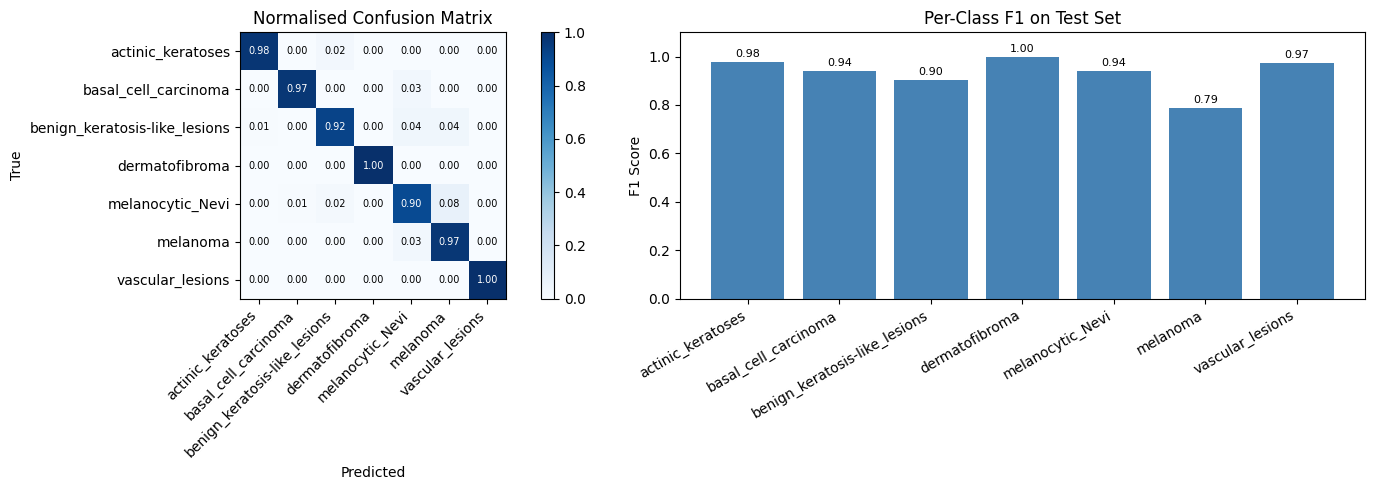

[INFO] Plot saved.


In [17]:
# Cell 12: Visualisation — confusion matrix + per-class metrics
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -- Confusion matrix --
cm = confusion_matrix(labels, preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(range(NUM_CLASSES)); axes[0].set_xticklabels(HAM_LABELS, rotation=45, ha="right")
axes[0].set_yticks(range(NUM_CLASSES)); axes[0].set_yticklabels(HAM_LABELS)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title("Normalised Confusion Matrix")
for r in range(NUM_CLASSES):
    for c in range(NUM_CLASSES):
        axes[0].text(c, r, f"{cm_norm[r,c]:.2f}",
                     ha="center", va="center", fontsize=7,
                     color="white" if cm_norm[r,c] > 0.5 else "black")
plt.colorbar(im, ax=axes[0])

# -- Per-class F1 bar chart --
per_f1 = f1_score(labels, preds, average=None, zero_division=0)
axes[1].bar(HAM_LABELS, per_f1, color="steelblue")
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Class F1 on Test Set")
plt.xticks(rotation=30, ha="right")
for i, v in enumerate(per_f1):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("/kaggle/working/ham10000_eval.png", dpi=150)
plt.show()
print("[INFO] Plot saved.")

In [ ]:
# Cell 11: Calibrate Per-Class Decision Thresholds
# ---------------------------------------------------------------------------
# Derives per-class decision thresholds from the *validation* split by
# maximising the per-class F1 score (or sensitivity / Youden's J) over a
# fine threshold grid.
#
# The test split is intentionally kept untouched so it remains a clean,
# unbiased held-out benchmark.
#
# Output
# ------
#   /kaggle/working/class_thresholds.json  -- drop-in replacement for the
#                                              hand-tuned file; compatible with
#                                              the backend's load_model() format.
#   /kaggle/working/calibration_curve.png  -- diagnostic plot
#
# Tune these three knobs before running the cell:
# ---------------------------------------------------------------------------
CALIB_METRIC  = "f1"        # "f1" | "sensitivity" | "youden"
CALIB_STEPS   = 99          # number of threshold candidates in [0.01, 0.99]
OUTPUT_JSON   = "/kaggle/working/class_thresholds.json"
# ---------------------------------------------------------------------------

import gc
import json
import os

import matplotlib
matplotlib.use("Agg")          # non-interactive backend -- safe in Kaggle
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from datasets import ClassLabel, load_dataset
from huggingface_hub import snapshot_download, upload_file
from peft import PeftModel
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from transformers import Dinov2Model
from PIL import Image

# -- Constants (mirrors training/config.py) -----------------------------------
DATASET_ID      = "marmal88/skin_cancer"
LABEL_FIELD     = "dx"
HUB_REPO        = "Ganymede981/ham10000-vit"
NUM_CLASSES     = 7
HAM_LABELS      = [
    "actinic_keratoses",
    "basal_cell_carcinoma",
    "benign_keratosis-like_lesions",
    "dermatofibroma",
    "melanocytic_Nevi",
    "melanoma",
    "vascular_lesions",
]
IMAGE_SIZE      = 224
NORMALIZE_MEAN  = [0.7630, 0.5456, 0.5700]
NORMALIZE_STD   = [0.1409, 0.1521, 0.1697]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Device: {DEVICE}")


# -- 1. Load the validation split ---------------------------------------------
print(f"[INFO] Loading dataset {DATASET_ID} ...")
raw          = load_dataset(DATASET_ID)
new_features = raw["train"].features.copy()
new_features[LABEL_FIELD] = ClassLabel(names=HAM_LABELS)

# Cast every official split so indices are consistent
for split in ("train", "validation", "test"):
    raw[split] = raw[split].cast(new_features)

val_raw = raw["validation"]   # 2,492 samples -- the split used for calibration
print(f"[INFO] Validation samples: {len(val_raw):,}")


# -- 2. PyTorch dataset (eval mode -- no augmentation) -------------------------
class HAMDataset(Dataset):
    def __init__(self, hf_split):
        self.data      = hf_split
        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        s   = self.data[idx]
        img = s.get("image", s.get("img"))
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img = img.convert("RGB")
        lbl = s[LABEL_FIELD]
        lbl = lbl if isinstance(lbl, int) else int(lbl)
        return {"pixel_values": self.transform(img), "labels": lbl}


def eval_collate_fn(batch):
    pixel_values = torch.stack([b["pixel_values"] for b in batch])
    labels       = torch.tensor([b["labels"] for b in batch], dtype=torch.long)
    return {"pixel_values": pixel_values, "labels": labels}


val_ds = HAMDataset(val_raw)
val_dl = DataLoader(
    val_ds, batch_size=64, shuffle=False,
    collate_fn=eval_collate_fn, num_workers=2, pin_memory=True,
)
print(f"[INFO] Validation DataLoader ready ({len(val_ds):,} samples).")


# -- 3. Rebuild the DINOv2+LoRA+Head model from the Hub -----------------------
# hf_token was set in Cell 1 via Kaggle Secrets; re-fetch it here so this
# cell can also be run standalone.
from kaggle_secrets import UserSecretsClient
hf_token = UserSecretsClient().get_secret("HF_TOKEN")

print(f"[INFO] Downloading model weights from {HUB_REPO} ...")
local_dir = snapshot_download(
    HUB_REPO,
    token=hf_token,
    local_dir="/kaggle/working/calib_model",
)
print(f"[INFO] Weights cached at {local_dir}")

base     = Dinov2Model.from_pretrained("facebook/dinov2-base")
lora_dir = os.path.join(local_dir, "dinov2_lora")
base     = PeftModel.from_pretrained(base, lora_dir)
base = base.to(DEVICE)

head = nn.Sequential(
    nn.LayerNorm(768 * 2),
    nn.Dropout(0.1),
    nn.Linear(768 * 2, NUM_CLASSES),
)
head.load_state_dict(
    torch.load(os.path.join(local_dir, "head.pt"), map_location="cpu")
)
head = head.to(DEVICE)


class DINOv2Classifier(nn.Module):
    """Inference-only wrapper -- identical forward pass to training."""
    def forward(self, pixel_values):
        out  = base(pixel_values=pixel_values)
        cls  = out.last_hidden_state[:, 0]
        mean = out.last_hidden_state[:, 1:].mean(dim=1)
        return head(torch.cat([cls, mean], dim=1))


gc.collect()
torch.cuda.empty_cache()
print(f"[INFO] GPU free before inference: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

model = DINOv2Classifier().to(DEVICE).eval()
print("[INFO] Model ready.")


# -- 4. Collect validation-set logits -> softmax probabilities -----------------
all_logits, all_labels = [], []
print("[INFO] Running inference on validation set ...")
with torch.no_grad():
    for batch in val_dl:
        logits = model(batch["pixel_values"].to(DEVICE)).cpu()
        all_logits.append(logits)
        all_labels.extend(batch["labels"].tolist())

logits = torch.cat(all_logits)
probs  = torch.softmax(logits.float(), dim=-1).numpy()   # (N, C)
labels = np.array(all_labels)                             # (N,)
print(f"[INFO] Collected {len(labels):,} validation samples.")


# -- 5. Per-class threshold search --------------------------------------------
def best_threshold_per_class(probs, labels, steps=99, metric="f1"):
    """
    For every class c, treat it as a binary problem:
        positive -> true label == c
        score    -> probs[:, c]

    Sweep threshold candidates and pick the one that maximises the
    chosen metric (f1 | sensitivity | youden).

    Returns
    -------
    thresholds : dict  {label_name: float}
    val_scores : dict  {label_name: float}
    curve_data : list of (label_name, grid, scores_along_grid)
    """
    grid       = np.linspace(0.01, 0.99, steps)
    thresholds = {}
    val_scores = {}
    curve_data = []

    for c, label in enumerate(HAM_LABELS):
        y_true     = (labels == c).astype(int)
        scores     = probs[:, c]
        best_thr   = 0.5
        best_score = -1.0
        score_grid = np.zeros(len(grid))

        for i, thr in enumerate(grid):
            y_pred = (scores >= thr).astype(int)

            if metric == "f1":
                s = f1_score(y_true, y_pred, zero_division=0)

            elif metric == "sensitivity":
                tp = int(((y_pred == 1) & (y_true == 1)).sum())
                fn = int(((y_pred == 0) & (y_true == 1)).sum())
                s  = tp / (tp + fn) if (tp + fn) > 0 else 0.0

            elif metric == "youden":
                tp = int(((y_pred == 1) & (y_true == 1)).sum())
                fn = int(((y_pred == 0) & (y_true == 1)).sum())
                tn = int(((y_pred == 0) & (y_true == 0)).sum())
                fp = int(((y_pred == 1) & (y_true == 0)).sum())
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
                s = sensitivity + specificity - 1.0

            else:
                raise ValueError(f"Unknown metric: {metric!r}")

            score_grid[i] = s
            if s > best_score:
                best_score = s
                best_thr   = thr

        thresholds[label] = round(float(best_thr),   4)
        val_scores[label] = round(float(best_score), 4)
        curve_data.append((label, grid, score_grid))
        print(f"  {label:<40s}  thr={best_thr:.4f}  {metric}={best_score:.4f}")

    return thresholds, val_scores, curve_data


print(f"\n[INFO] Optimising thresholds (metric={CALIB_METRIC}, steps={CALIB_STEPS}) ...\n")
thresholds, val_scores, curve_data = best_threshold_per_class(
    probs, labels, steps=CALIB_STEPS, metric=CALIB_METRIC
)


# -- 6. Diagnostic plot -------------------------------------------------------
def save_calibration_plot(curve_data, thresholds, metric, out_path):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()

    for i, (label, grid, scores) in enumerate(curve_data):
        ax         = axes[i]
        best_thr   = thresholds[label]
        best_score = scores[np.argmin(np.abs(grid - best_thr))]

        ax.plot(grid, scores, linewidth=1.5, color="steelblue")
        ax.axvline(best_thr, color="tomato", linestyle="--", linewidth=1.2,
                   label=f"thr={best_thr:.4f}")
        ax.scatter([best_thr], [best_score], color="tomato", zorder=5)
        ax.set_title(label, fontsize=8)
        ax.set_xlabel("Threshold", fontsize=7)
        ax.set_ylabel(metric, fontsize=7)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

    # Hide the spare subplot (7 classes -> 8th cell unused)
    if len(curve_data) < len(axes):
        axes[-1].set_visible(False)

    fig.suptitle(
        f"Threshold calibration -- maximising per-class {metric}", fontsize=11
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()
    print(f"[INFO] Calibration plot saved to {out_path}")


plot_path = os.path.splitext(OUTPUT_JSON)[0] + "_calibration_curve.png"
save_calibration_plot(curve_data, thresholds, CALIB_METRIC, plot_path)


# -- 7. Write class_thresholds.json -------------------------------------------
output = {
    "thresholds":         thresholds,
    "val_f1":             val_scores,
    "calibration_metric": CALIB_METRIC,
    "calibration_steps":  CALIB_STEPS,
    "labels":             HAM_LABELS,
    "model_repo":         HUB_REPO,
}
with open(OUTPUT_JSON, "w") as f:
    json.dump(output, f, indent=2)
print(f"\n[INFO] Thresholds saved to {OUTPUT_JSON}")


# -- 8. Upload to Hub alongside the model weights ----------------------------
upload_file(
    path_or_fileobj=OUTPUT_JSON,
    path_in_repo="class_thresholds.json",
    repo_id=HUB_REPO,
    token=hf_token,
    commit_message=f"Add calibrated thresholds (metric={CALIB_METRIC})",
)
print("[INFO] class_thresholds.json pushed to Hub.")


# -- 9. Summary table ---------------------------------------------------------
print("\n-- Calibrated thresholds --------------------------------------------------")
print(f"{'Class':<40s}  {'Threshold':>9}  {CALIB_METRIC:>12}")
print("-" * 66)
for label in HAM_LABELS:
    print(f"  {label:<38s}  {thresholds[label]:>9.4f}  {val_scores[label]:>12.4f}")
print("-" * 66)
print(
    "\nDrop the generated class_thresholds.json into your backend cache or "
    "model repo to activate the calibrated thresholds.\n"
)
